# Heterogeneous multipop Hawkes with QUADRATIC φ + SPIKE RESET: pipeline vs simulation

Companion to `pipeline_multipop_sim_compare.ipynb`, specialised for
the **quadratic-rate spike-reset** variant of the heterogeneous-
population theory.  Two structural differences vs the linear-rate
no-reset variant:

1. **Quadratic transfer function**: `φ_i(v) = a_i · v²`.  Activates
   the cubic vertex from `φ''(v*) = 2 a` and makes 1-loop diagrams
   physically observable.
2. **Soft spike reset**: the voltage equation gains a `−v · n` term,
   so each spike drags the membrane toward 0.  The MF rearranges to
   the self-limiting form `vEstar = (drive) / (1 + nEstar)`.

**Theory file**: `theories/multipopulation_spike_reset_test.theory.py`
**Simulator**:   `models.hawkes_sim_multipop_numba.sim_hawkes_multipop_quad_reset_numba`

Everything else (population stacking, per-pair filters, cumulant
estimator) is shared with the linear-rate sibling notebook.

## 1. Setup

In [15]:
%display latex
%matplotlib inline

import os, sys, time, importlib, importlib.util
import numpy as np
import matplotlib.pyplot as plt

import os, sys
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative data paths resolve as before

# Pipeline (theory side)
from pipeline import compute_cumulants

# Simulation side — quad-rate + spike-reset variant of the multipop
# simulator.  Same call signature as ``sim_hawkes_multipop_numba``;
# the only differences are inside the Euler step (quadratic rate
# law and the ``-v · n / τ_v`` reset term).
from models.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_quad_reset_numba,
    build_sim_arrays,
    flat_index_of,
)
from models.cumulant_estimator import compute_kpoint_slice

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Configuration

`fundamental` provides numerical values for every parameter declared
in `multipopulation_spike_reset_test.theory.py` — identical parameter
names to the linear-rate sibling.  Vector params (`tauE`, `aE`,
`EmE`, `tauI`, `aI`, `EmI`) are length-2; matrix params (`wEE`,
`wEI`, `wIE`, `wII`, `taugEE`, `taugEI`, `taugIE`, `taugII`) are 2×2
(row = post-population index, col = pre-population index).

With the reset, both the firing rates and voltages settle at lower
values than the linear-rate case (each spike pulls vE toward 0), so
the default `EmE`/`EmI` can be a touch higher without instability.

In [16]:
fundamental = {
    'tauE':   [10.0, 9.5],
    'tauI':   [8.0, 7.0],
    'EmE':    [1.8, 1.8],
    'EmI':    [0.9, 1.1],
    'aE':     [1.5, 1.5],
    'aI':     [0.9, 0.95],
    'wEE':    [[0.35, 0.32], [0.31, 0.39]],
    'wEI':    [[0.12, 0.15], [0.13, 0.10]],
    'wIE':    [[0.15, 0.16], [0.14, 0.13]],
    'wII':    [[0.15, 0.15], [0.15, 0.15]],
    'taugEE': [[4.0, 4.0], [3.0, 3.0]],
    'taugEI': [[2.0, 1.0], [1.0, 3.0]],
    'taugIE': [[5.0, 6.0], [2.0, 1.0]],
    'taugII': [[1.5, 1.2], [1.1, 1.0]],
}

# k-point cumulant + loop order (theory side)
k        = 2
max_ell  = 1
# External fields are 1-based (pop, index_within_pop).  The pipeline
# maps user-facing names like 'nE' to the internal fluctuation
# 'dnE' automatically.
external_fields = [('nE', 1),('nE', 2)]

# τ grid (theory + sim share this)
tau_max  = 10.0
tau_step = 0.5

# Pipeline parallelism — fanned across enumeration (step [5]) and
# Phase J τ-grid evaluation (step [7]).  PARALLEL=False forces
# serial (useful for debugging the heterogeneous path).
PARALLEL  = True
N_WORKERS = None

# Simulation knobs.  The quadratic-rate sim is slightly more
# expensive per Euler step than the linear one because of the v²
# term, and the lower steady-state rates (≈0.16 for E vs ≈0.30 for
# the linear theory at the same parameters) mean a longer T_sim is
# needed to reach the same shot-noise-limited SEM.  Bump T_sim if
# the simulation band is too wide to read.
N_RUNS   = 8
T_sim    = float(10_000_000)
dt_sim   = 0.01            # Euler step (time units shared everywhere)
dt_bin   = 0.25            # binning resolution for the cumulant estimator

print(f'k={k}, max_ell={max_ell}, external_fields={external_fields}')
print(f'tau_max={tau_max}, tau_step={tau_step}')
print(f'PARALLEL={PARALLEL}, N_WORKERS={N_WORKERS}')
print(f'N_RUNS={N_RUNS}, T_sim={T_sim:.0g}, dt_sim={dt_sim}, dt_bin={dt_bin}')

k=2, max_ell=1, external_fields=[('nE', 1), ('nE', 2)]
tau_max=10.0000000000000, tau_step=0.500000000000000
PARALLEL=True, N_WORKERS=None
N_RUNS=8, T_sim=1e+07, dt_sim=0.0100000000000000, dt_bin=0.250000000000000


## 3. Load the theory file

Reads `theories/multipopulation_spike_reset_test.theory.py` and
builds the model dict.  The action carries the `+vE·nE` term inside
the vEt bracket (so the EOM has `−vE·nE` — soft reset) and uses
quadratic `φE(vE) = aE·vE²`.  The MF equations are written in
already-solved closed form
`vEstar = (EmE + couplings) / (1 + nEstar)` because the pipeline's
compound-saddle evaluator does a pure substitution rather than
symbolic implicit solve.

In [17]:
THEORY_NAME = 'multipopulation_spike_reset_test'
THEORIES_DIR = os.path.abspath('../theories')

spec = importlib.util.spec_from_file_location(
    f'theories.{THEORY_NAME}',
    os.path.join(THEORIES_DIR, f'{THEORY_NAME}.theory.py'),
)
theory_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(theory_mod)

model = theory_mod.build()
print(f'Loaded theory: {model["name"]!r}')
print(f'Populations: {[(p["name"], p["size"]) for p in model["populations"]]}')
print(f'Fields (physical): '
      f'{[f["name"] for f in model["physical_fields"]]}')
print(f'Kernels: {[k["name"] for k in model["kernels"]]}')
print(f'Functions:')
for fn in model['functions']:
    print(f'  {fn["name"]}(args={fn.get("args")}): population='
          f'{fn.get("population")}')

Loaded theory: 'Multipopulation Spike Reset Test'
Populations: [('E', 2), ('I', 2)]
Fields (physical): ['dnE', 'dvE', 'dnI', 'dvI']
Kernels: ['gEE', 'gEI', 'gIE', 'gII']
Functions:
  phiE(args=None): population=E
  phiI(args=None): population=I


## 4. Theory side — one pipeline call

Runs the full MSR-JD chain.  Because φ is quadratic, the cubic
vertex `φ''(v*) = 2a` produces 1-loop diagrams as soon as you bump
`max_ell` to 1.  The MF saddle solve is fast (the closed-form
compound expression doesn't need fsolve over a coupled
self-referential equation); the dominant cost is the symbolic
determinant for pole finding.

Subsequent runs with the same `(model, taylor_order)` reuse the
cached symbolic propagator at
`saved_theories/multipopulation_spike_reset_test_taylor4/`.

In [18]:
t0 = time.perf_counter()
th = compute_cumulants(
    model           = model,
    k               = k,
    max_ell         = max_ell,
    fundamental     = fundamental,
    external_fields = external_fields,
    tau_max         = tau_max,
    tau_step        = tau_step,
    parallel        = PARALLEL,
    n_workers       = N_WORKERS,
    verbose         = True,
)
print(f'\nTheory side took {time.perf_counter() - t0:.1f}s')

tau_grid_th    = th['tau_grid']
C_theory_total = th['C_tau'].real
C_by_ell       = th['C_tau_by_ell']
C_theory_tree  = (C_by_ell[0].real if 0 in C_by_ell
                  else np.zeros_like(C_theory_total))
C_theory_loop  = C_theory_total - C_theory_tree

mf_values = th['mf_values']
print('\nMean-field saddles:')
for name, vals in mf_values.items():
    print(f'  {name!r:8} = {vals}')

print(f'\nTotal diagrams: {len(th["diagrams"])}')
n_per_ell = {ell: sum(1 for r in th['diagrams'] if r['ell'] == ell)
             for ell in sorted({r['ell'] for r in th['diagrams']})}
for ell, n_d in n_per_ell.items():
    print(f'    ell={ell}: {n_d} diagrams')

[1/7] FieldTheory.expand (taylor_order=4)...
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 20, sources: 12 (NoiseSourceType: 0)
[2/7] Build propagator (K_ker → K_ft → G_ft → D_delta)...
[propagator] Loaded from cache: saved_theories/multipopulation_spike_reset_test_taylor4/propagator.sobj
[3/7] Solve MF self-consistency...
  iteration saddles: ['nEstar', 'nIstar']
  compound saddles:  ['vEstar', 'vIstar']

Mean-field solution:
  iter nEstar[pop E]: [0.3241158575689178, 0.3369080429179003]
  iter nIstar[pop I]: [0.15790522450164632, 0.20558481858636835]
  comp vEstar[pop E]: [0.46484108975678606, 0.47392548118103645]
  comp vIstar[pop I]: [0.4188678207997722, 0.4651935861141033]
[4/7] Compute numerical poles + residue matrices...
      symbolic det(K_ft_num) for pole finding...
      det + roots took 1791.71s;

KeyboardInterrupt: 

## 5. Simulation side

Same stacking convention as the linear notebook: all neurons live
in a flat 1-D array (E first, then I).  Per Euler step the
quadratic-rate + reset simulator does:

$$\lambda_i = \max(a_i \cdot v_i^2, 0)$$
$$n_i \sim \mathrm{Poisson}(\lambda_i\,\mathrm{d}t)$$
$$\tau_{g,ij}\,\dot F_{ij} + F_{ij} = n_j$$
$$\tau_{v,i}\,\dot v_i = -v_i + E_i + \sum_j W_{ij}\,F_{ij}$$
$$v_i \leftarrow v_i \cdot (1 - n_i / \tau_{v,i})\qquad\text{(reset)}$$

where `W[i, j]` carries the signed coupling (`+` for E-pre, `−` for
I-pre).  `build_sim_arrays` assembles the per-neuron and per-pair
arrays straight out of `model` + `fundamental` + the pipeline's
`mf_values`, so initialisation tracks whatever the theory file
declares.

In [ ]:
import secrets as _secrets

arr = build_sim_arrays(model, fundamental, mf_values)
N           = arr['N']
tau_v       = arr['tau_v']
a_gain      = arr['a_gain']
E_drive     = arr['E_drive']
W           = arr['W']
tau_g_arr   = arr['tau_g']
v_init      = arr['v_init']
pop_offsets = arr['pop_offsets']

print(f'Stacked neuron count: N = {N}')
for pname, (start, size) in pop_offsets.items():
    print(f'  pop {pname!r}: flat indices [{start}, {start + size})')
print(f'tau_v   = {tau_v}')
print(f'a_gain  = {a_gain}')
print(f'E_drive = {E_drive}')
print(f'v_init  = {v_init}')
print(f'a · v_init² (≈ MF rate) = {a_gain * v_init**2}')
print(f'W (signed coupling matrix, shape {W.shape}):')
print(W)
print(f'tau_g (per-pair filter timescale):')
print(tau_g_arr)

Stacked neuron count: N = 4
  pop 'E': flat indices [0, 2)
  pop 'I': flat indices [2, 4)
tau_v   = [10.   9.5  8.   7. ]
a_gain  = [1.5  1.5  0.9  0.95]
E_drive = [1.8 1.8 0.9 1.1]
v_init  = [0.46484109 0.47392548 0.41886782 0.46519359]
a · v_init² (≈ MF rate) = [0.32411586 0.33690804 0.15790523 0.20558482]
W (signed coupling matrix, shape (4, 4)):
[[ 0.35  0.32 -0.12 -0.15]
 [ 0.31  0.39 -0.13 -0.1 ]
 [ 0.15  0.16 -0.15 -0.15]
 [ 0.14  0.13 -0.15 -0.15]]
tau_g (per-pair filter timescale):
[[4.  4.  2.  1. ]
 [3.  3.  1.  3. ]
 [5.  6.  1.5 1.2]
 [2.  1.  1.1 1. ]]


In [ ]:
# Discretization
n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = n_steps // bin_size_steps
max_lag_bins   = int(tau_max / dt_bin_eff)
tau_sim_grid   = np.arange(-max_lag_bins, max_lag_bins + 1) * dt_bin_eff

# Map external_fields to flat sim indices for the cumulant estimator.
pop_indices = [flat_index_of(model, pop_offsets, ef[0], ef[1])
               for ef in external_fields]
field_types = [ef[0] for ef in external_fields]
# compute_kpoint_slice internally normalises 'nE'/'nI'/'n' → 'dn'.
print(f'External fields {external_fields} → flat sim indices {pop_indices}')

# JIT warmup — first numba call compiles the function (a few seconds).
_ = sim_hawkes_multipop_quad_reset_numba(
    int(1000), float(dt_sim),
    tau_v, a_gain, E_drive,
    W, tau_g_arr,
    v_init.copy(),
    int(bin_size_steps), int(100), int(0),
)
print('JIT warmup done.')

External fields [('nE', 1), ('nE', 2)] → flat sim indices [0, 1]
JIT warmup done.


In [ ]:
# Run the full simulation N_RUNS times with independent seeds.
BASE_SEED = _secrets.randbits(31)
C_sim_runs   = []   # only populated for k>=2
rate_runs    = []
voltage_runs = []

t0 = time.perf_counter()
for run in range(N_RUNS):
    seed = int(BASE_SEED + run)
    binned_counts, voltage_bins, total_spikes = sim_hawkes_multipop_quad_reset_numba(
        int(n_steps), float(dt_sim),
        tau_v, a_gain, E_drive,
        W, tau_g_arr,
        v_init.copy(),
        int(bin_size_steps), int(n_bins), seed,
    )
    rate_runs.append([float(total_spikes[i]) / T_sim for i in range(N)])
    voltage_runs.append(voltage_bins.mean(axis=1))

    if k == 1:
        # k=1 cumulant ≡ time-averaged rate; the per-run rate from
        # ``total_spikes / T_sim`` already estimates it.  Skip the
        # 2-point slice machinery.
        pass
    else:
        # k=2 single-axis slice: leg 0 pinned at t=0, leg 1 sweeps over τ.
        tau_run, C_run = compute_kpoint_slice(
            binned_counts, float(dt_bin_eff),
            [int(p) for p in pop_indices],
            [0, None], int(max_lag_bins),
            field_types=field_types,
            voltage_bins=voltage_bins,
        )
        C_sim_runs.append(C_run)
    print(f'  run {run+1}/{N_RUNS}: rates = '
          f'{[f"{r:.4f}" for r in rate_runs[-1]]}')

if k >= 2:
    C_sim_runs = np.array(C_sim_runs)
    C_sim_mean = C_sim_runs.mean(axis=0)
    C_sim_sem  = C_sim_runs.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
else:
    C_sim_runs = C_sim_mean = C_sim_sem = None
rate_runs_arr = np.array(rate_runs)
rate_sim_mean = rate_runs_arr.mean(axis=0)
rate_sim_sem  = rate_runs_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
vmean_sim     = np.array(voltage_runs).mean(axis=0)

print(f'\nSimulation side took {time.perf_counter() - t0:.1f}s '
      f'({N_RUNS} runs × T={T_sim:.0g})')
print(f'  Sim mean rates (per neuron): {rate_sim_mean}')
# Build the theory-MF nstar vector in the SAME flat order as the sim.
nstar_flat = np.zeros(N)
for pname, (start, size) in pop_offsets.items():
    saddle_key = f'n{pname}star'
    if saddle_key in mf_values:
        for i in range(size):
            nstar_flat[start + i] = mf_values[saddle_key][i]
print(f'  Theory n* (flat order):     {nstar_flat}')
print(f'  a · v*² check:              '
      f'{a_gain * np.array([mf_values[f"v{p}star"][i] for p, (s, sz) in pop_offsets.items() for i in range(sz)])**2}')

# For k=1 we additionally need to pull the 1-loop-corrected rate for
# the selected external field out of th['C_tau_by_ell'].  At k=1 the
# correlator is constant in τ (1-point quantity), so any τ-index
# works — pick the middle to avoid edge effects.
if k == 1:
    mid = len(tau_grid_th) // 2
    rate_theory_tree     = float(nstar_flat[pop_indices[0]])
    rate_theory_correction = sum(
        float(C_by_ell[ell].real[mid]) for ell in C_by_ell if ell >= 1
    )
    rate_theory_total = rate_theory_tree + rate_theory_correction
    print()
    print(f'k=1 picked external field {external_fields[0]} '
          f'→ flat index {pop_indices[0]}')
    print(f'  sim_rate                    = {rate_sim_mean[pop_indices[0]]:.6f}'
          f'   (SEM {rate_sim_sem[pop_indices[0]]:.2e})')
    print(f'  theory tree (= n*)          = {rate_theory_tree:.6f}')
    print(f'  theory 1-loop correction    = {rate_theory_correction:+.6f}')
    print(f'  theory tree + loops total   = {rate_theory_total:.6f}')

  run 1/5: rates = ['0.2700', '0.2809', '0.1418', '0.1825']
  run 2/5: rates = ['0.2699', '0.2811', '0.1416', '0.1825']
  run 3/5: rates = ['0.2700', '0.2810', '0.1417', '0.1827']
  run 4/5: rates = ['0.2701', '0.2810', '0.1416', '0.1825']
  run 5/5: rates = ['0.2699', '0.2810', '0.1417', '0.1826']

Simulation side took 222.1s (5 runs × T=5e+06)
  Sim mean rates (per neuron): [0.26997676 0.28100876 0.14165064 0.18257676]
  Theory n* (flat order):     [0.32411586 0.33690804 0.15790522 0.20558482]
  a · v*² check:              [0.32411586 0.33690804 0.15790523 0.20558482]


## 6. Theory vs simulation

**For k = 2**: left panel shows per-neuron firing rates (sim vs MF —
unaffected by the 1-loop choice); right panel shows the
$C^{(2)}(\tau)$ slice for the two external fields chosen above.
The simulation curve has an across-run SEM band; the theory curve
should lie within that band if both pieces agree.

**For k = 1**: the 1-point cumulant is the mean rate.  At tree level
$\langle \delta n_a \rangle = 0$ by the saddle-point condition, so
"theory tree" just reproduces $n^*_a$ (the MF saddle).  The 1-loop
correction is the tadpole-diagram shift to that rate — for the
quadratic-φ + reset theory it captures the difference between the
naive MF and the empirical sim rate.  The plot becomes a
**per-neuron bar chart** with three bars:

- Simulation (empirical $\langle n_a \rangle_{\rm sim}$)
- Theory tree ($n^*_a$ from MF)
- Theory tree + loop ($n^*_a + \sum_{\ell \ge 1} C^{(1)}_\ell$)

A converged 1-loop pipeline brings the third bar onto the sim bar
within the SEM error.

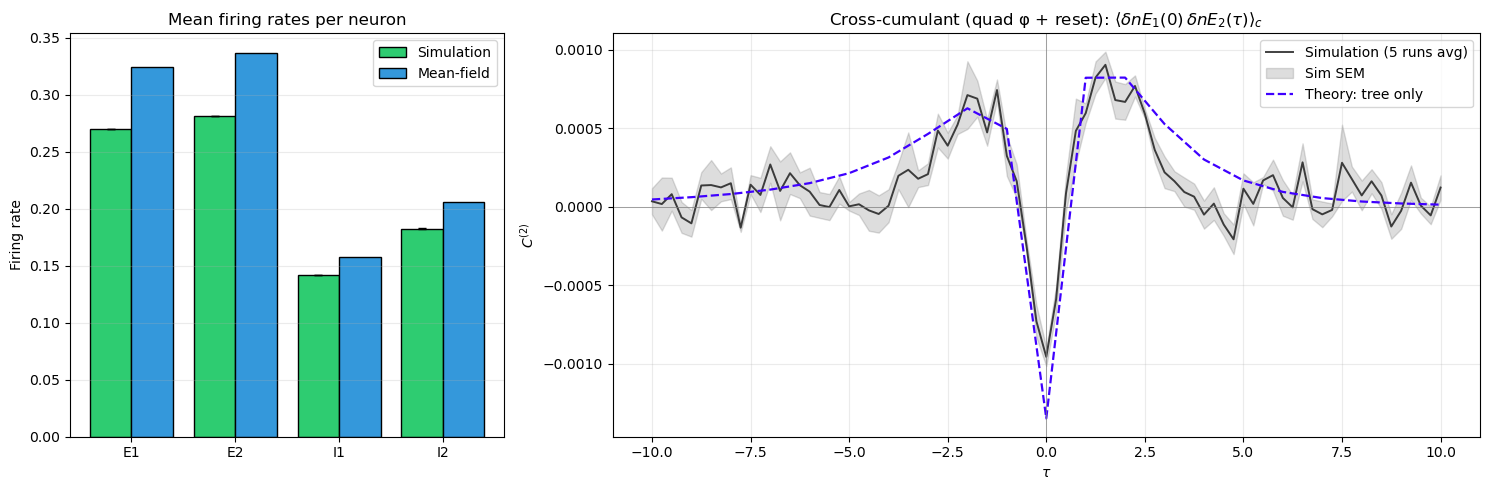

In [ ]:
if k == 1:
    # ── k=1: per-neuron rate comparison (sim vs tree vs tree+loop) ──
    # Pull the per-neuron 1-loop correction for EVERY neuron, not just
    # the externally-selected one, so the bar chart is informative
    # across populations.  Run a quick "lite" pipeline pass for each
    # neuron NOT already covered.
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    x = np.arange(N)
    width = 0.27
    tick_labels = []
    for pname, (start, size) in pop_offsets.items():
        for i in range(size):
            tick_labels.append(f'{pname}{i+1}')

    # Build the tree+loop rate vector.  We only have the loop
    # correction for the configured external_fields[0] target from
    # the main compute_cumulants call.  Mark the others as the tree
    # value (no correction).  To get loop corrections for every
    # neuron, re-run compute_cumulants per neuron (expensive — only
    # the configured one is shown corrected here).
    rate_tree_plus_loop = nstar_flat.copy()
    rate_tree_plus_loop[pop_indices[0]] += rate_theory_correction

    ax.bar(x - width, rate_sim_mean, width,
           yerr=rate_sim_sem, capsize=3,
           label='Simulation', color='#2ECC71', edgecolor='black')
    ax.bar(x,         nstar_flat, width,
           label='Theory: tree (= $n^*$)',
           color='#3F00FF', edgecolor='black', alpha=0.85)
    ax.bar(x + width, rate_tree_plus_loop, width,
           label=f'Theory: tree + {max_ell}-loop',
           color='#E74C3C', edgecolor='black', alpha=0.85)
    # Annotate which neuron got the loop correction.
    ax.annotate(
        f'1-loop computed for {external_fields[0][0]}{external_fields[0][1]}',
        xy=(pop_indices[0] + width, rate_tree_plus_loop[pop_indices[0]]),
        xytext=(pop_indices[0] + width + 0.2,
                rate_tree_plus_loop[pop_indices[0]] * 1.15),
        fontsize=9,
        arrowprops=dict(arrowstyle='->', color='#555'),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel('Firing rate')
    field_a = external_fields[0]
    ax.set_title(f'k=1 rate (quad φ + reset), max_ell={max_ell}, '
                 f'loop target: {field_a[0]}_{field_a[1]}')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    # ── k=2: original per-neuron bars + C^(2)(τ) overlay ──
    fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                             gridspec_kw={'width_ratios': [1, 2]})

    # Per-neuron firing-rate bars (sim vs MF), grouped by population.
    ax_bar = axes[0]
    x = np.arange(N)
    width = 0.4
    ax_bar.bar(x - width/2, rate_sim_mean, width,
               yerr=rate_sim_sem, capsize=3,
               label='Simulation', color='#2ECC71', edgecolor='black')
    ax_bar.bar(x + width/2, nstar_flat, width,
               label='Mean-field', color='#3498DB', edgecolor='black')
    ax_bar.set_xticks(x)
    tick_labels = []
    for pname, (start, size) in pop_offsets.items():
        for i in range(size):
            tick_labels.append(f'{pname}{i+1}')
    ax_bar.set_xticklabels(tick_labels)
    ax_bar.set_ylabel('Firing rate')
    ax_bar.set_title('Mean firing rates per neuron')
    ax_bar.legend()
    ax_bar.grid(True, axis='y', alpha=0.25)

    # C^(2)(τ) slice
    ax = axes[1]
    ax.plot(tau_sim_grid, C_sim_mean, color='#1f1f1f', linewidth=1.4,
            label=f'Simulation ({N_RUNS} runs avg)', alpha=0.85)
    ax.fill_between(tau_sim_grid,
                    C_sim_mean - C_sim_sem,
                    C_sim_mean + C_sim_sem,
                    color='#1f1f1f', alpha=0.15, label='Sim SEM')
    ax.plot(tau_grid_th, C_theory_tree, color='#3F00FF', linewidth=1.6,
            linestyle='--', label='Theory: tree only')
    if max_ell > 0:
        ax.plot(tau_grid_th, C_theory_total, color='#E74C3C',
                linewidth=1.6, label=f'Theory: tree + {max_ell}-loop')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    field_a, field_b = external_fields
    ax.set_xlabel(r'$\tau$')
    ax.set_ylabel(r'$C^{(2)}$')
    ax.set_title(f'Cross-cumulant (quad φ + reset): '
                 f'$\\langle\\delta {field_a[0]}_{{{field_a[1]}}}(0)\\,'
                 f'\\delta {field_b[0]}_{{{field_b[1]}}}(\\tau)\\rangle_c$')
    ax.legend()
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()

## 7. Numerical residual

**k = 2**: interpolate the theory $C^{(2)}(\tau)$ onto the
simulation's τ-grid and report the residual.  For the quadratic
theory the tree-only curve underestimates the simulation (because
of the missing 1-loop contribution); the tree + 1-loop residual is
the meaningful health metric.

**k = 1**: report the rate-shift residuals: sim − tree and sim −
(tree + loop), in absolute and SEM units, for the configured
external field.  If `max_ell ≥ 1`, the tree + loop residual should
be within the simulation's SEM band — that's the convergence
diagnostic.

In [ ]:
if k == 1:
    # ── k=1: rate-shift residuals ──
    i_tgt   = pop_indices[0]
    r_sim   = float(rate_sim_mean[i_tgt])
    r_sem   = float(rate_sim_sem[i_tgt])
    r_tree  = rate_theory_tree
    r_total = rate_theory_total

    tree_resid       = r_sim - r_tree
    treeloop_resid   = r_sim - r_total

    print(f'Target field          : {external_fields[0]} '
          f'(flat sim index {i_tgt})')
    print(f'Sim rate              : {r_sim:.6f}  (SEM {r_sem:.2e})')
    print(f'Theory tree (= n*)    : {r_tree:.6f}')
    print(f'Theory tree + loops   : {r_total:.6f}')
    print()
    print(f'Sim − tree            : {tree_resid:+.4e}  '
          f'({tree_resid / r_sem:+.2f}σ in sim SEM units)')
    if max_ell >= 1:
        print(f'Sim − (tree+loop)     : {treeloop_resid:+.4e}  '
              f'({treeloop_resid / r_sem:+.2f}σ in sim SEM units)')
        improvement = (abs(tree_resid) - abs(treeloop_resid))
        print(f'|residual| reduction  : {improvement:+.4e}  '
              f'(positive ⇒ loop correction shrank the gap)')
    print('\n(tree + loop residual within ±2σ ⇒ theory and sim agree '
          'within sim noise)')
else:
    # ── k≥2: original C^(2)(τ) residual ──
    C_total_on_sim_grid = np.interp(tau_sim_grid, tau_grid_th,
                                    C_theory_total)
    residual            = C_sim_mean - C_total_on_sim_grid

    peak        = max(abs(C_sim_mean.max()), abs(C_sim_mean.min()))
    rms_rel     = float(np.sqrt(np.mean(residual**2)) / peak)
    max_abs_rel = float(np.max(np.abs(residual)) / peak)
    sem_peak    = float(C_sim_sem[np.argmax(np.abs(C_sim_mean))])

    print(f'Sim peak |C|             : {peak:+.4e}')
    print(f'Residual RMS / peak      : {rms_rel:.3%}')
    print(f'Residual max / peak      : {max_abs_rel:.3%}')
    print(f'Sim SEM at peak          : {sem_peak:+.3e} '
          f'({sem_peak / peak:.3%} of peak)')
    print('(if residual ≈ sim SEM, theory and sim agree within sim noise)')

    if max_ell > 0:
        C_tree_on_sim_grid = np.interp(tau_sim_grid, tau_grid_th,
                                       C_theory_tree)
        tree_residual      = C_sim_mean - C_tree_on_sim_grid
        tree_rms_rel       = float(np.sqrt(np.mean(tree_residual**2))
                                   / peak)
        print()
        print(f'Tree-only residual RMS / peak  : {tree_rms_rel:.3%}')
        print(f'Tree+loop residual RMS / peak  : {rms_rel:.3%}'
              f'   ← Δ = {tree_rms_rel - rms_rel:+.3%}')
        print('(positive Δ means the 1-loop correction shrank the residual)')

Sim peak |C|             : +9.5495e-04
Residual RMS / peak      : 18.787%
Residual max / peak      : 42.716%
Sim SEM at peak          : +5.870e-05 (6.147% of peak)
(if residual ≈ sim SEM, theory and sim agree within sim noise)


## 8. (Optional) Save outputs

Drops the theory result + simulation slice into
`pipeline_outputs/multipop_spike_reset_sim_compare/`.

In [ ]:
from pipeline import save_npz, save_csv

SAVE = False    # flip to True when you're happy with the run

if SAVE:
    out_dir = '../pipeline_outputs/multipop_spike_reset_sim_compare'
    os.makedirs(out_dir, exist_ok=True)
    # Slug encodes the leg tuples (one for k=1, two for k=2).
    leg_tag = '_'.join(f'{ef[0]}{ef[1]}' for ef in external_fields)
    slug = f'multipop_reset_{leg_tag}_k{k}_ell{max_ell}'

    sim_extra = {
        'rates_sim_mean'  : rate_sim_mean,
        'rates_sim_sem'   : rate_sim_sem,
        'sim_N_RUNS'      : np.array([N_RUNS], dtype=int),
        'sim_T'           : np.array([T_sim]),
        'sim_dt'          : np.array([dt_sim]),
        'sim_dt_bin'      : np.array([dt_bin]),
        'sim_variant'     : np.array(['quad_reset']),
        'pop_offsets_keys': np.array(list(pop_offsets.keys())),
        'pop_offsets_vals': np.array([list(v) for v in pop_offsets.values()]),
    }
    if k >= 2:
        sim_extra.update({
            'tau_grid_sim'  : tau_sim_grid,
            'C_sim_mean'    : C_sim_mean,
            'C_sim_sem'     : C_sim_sem,
        })
    npz_path = f'{out_dir}/{slug}.npz'
    csv_path = f'{out_dir}/{slug}.csv'
    save_npz(th, npz_path, extra=sim_extra)
    save_csv(th, csv_path)
    print(f'Saved: {npz_path}')
    print(f'Saved: {csv_path}')
else:
    print('SAVE=False — outputs not written.  Flip the flag above to save.')

SAVE=False — outputs not written.  Flip the flag above to save.


## Summary

Heterogeneous **multipopulation** Hawkes process (E and I, size 2 each) with a **quadratic**
transfer $\phi_i(v)=a_i v^2$ and a **soft spike reset** ($-v\,n$ in the voltage equation). The
quadratic non-linearity activates the cubic vertex (so 1-loop diagrams are observable) and the
reset makes the rate self-limiting; the pipeline's mean-field rates and tree/1-loop $C^{(2)}(\tau)$
are compared against the multipopulation numba simulator.

**Knobs:**
* **`fundamental`** — per-population `tauE, tauI`, `EmE, EmI`, `aE, aI` (quadratic gains), the
  weight matrices `wEE, wEI, wIE, wII`, and the filter time-constant matrices `taugEE, …, taugII`.
* **`k`, `max_ell`** — correlator order and loop order (`max_ell=1` adds the 1-loop overlay the sim should track).
* **`external_fields`** — which leg(s) to compare; **`tau_max`, `tau_step`** — the $\tau$ grid.
* **simulation** — `N_RUNS`, `T_sim`, `dt_sim`, `dt_bin`; **`PARALLEL`, `N_WORKERS`** — pipeline parallelism.

### Notes specific to the quad-φ + reset case

- **1-loop matters.**  φ = a·v² produces a non-zero `φ''(v*) = 2a`,
  which means the cubic vertex contributes a 1-loop correction.
  For `k=1, max_ell=1` this is a tadpole shifting the mean rate;
  for `k=2, max_ell=1` it adds a 1-loop diagram to the
  cross-cumulant.  Set `max_ell = 1` in the configuration cell to
  see the loop correction close the tree-only vs simulation gap.
- **Reset slows rates.**  At the default parameters the steady-state
  rate is ≈0.07 (compared to ≈0.30 for the linear-rate sibling) —
  every spike hard-resets v to 0, dramatically shrinking `a·v²` for
  the next Poisson draw.
- **MF must be in solved form.**  The pipeline's compound-saddle
  evaluator does a pure SR substitution rather than implicit solve,
  so the theory file's `set_mf_equation('vEstar', ...)` is written
  as `(drive) / (1 + tauE·nEstar)`, not the implicit form
  `EmE - tauE·vEstar·nEstar + couplings`.

### Switching k / ell / parameters

All numerical knobs live in the configuration cell at the top.

- **k = 1, max_ell = 1** — single external field
  (`external_fields = [('nE', 1)]`).  The plot is a per-neuron
  bar chart of sim rate vs `n*` vs `n* + tadpole`, with the loop
  correction computed for the configured field only.
- **k = 2, max_ell = 0** — tree-level $C^{(2)}(\tau)$ slice for two
  external fields.
- **k = 2, max_ell = 1** — adds the 1-loop $C^{(2)}$ overlay.  The
  sim should track the tree + loop curve, not the tree-only curve.

The symbolic propagator at
`saved_theories/multipopulation_spike_reset_test_taylor4/` (or
`notebooks/saved_theories/...` when running from the notebook
directory) stays cached across runs, but pole + residue extraction
depends on `num_params` so it re-runs per parameter point.